# 07 — ML Dataset Design (⛔ DECISION GATE)

**Ini titik paling penting di seluruh proyek.** Di sini kita:
1. Lihat distribusi tanggal `order_purchase_timestamp` yang sebenarnya (bukan asumsi)
2. **Sensitivity analysis** — coba beberapa panjang prediction window (3/4/6 bulan), bandingkan positive cases & rate
3. Pilih window final berdasarkan **business horizon**, bukan cuma cari imbalance yang "paling enak"
4. Definisikan eligible population (Fase 7.0) & target secara presisi
5. Leakage audit, feature engineering, time-based split
6. Simpan dataset final untuk modeling

> ⚖️ Prinsip: **Roadmap = baseline, data aktual = hakimnya.** Kalau imbalance ekstrem, jangan langsung "ubah datanya" — investigasi dulu apakah itu karakteristik bisnis yang valid (short-term repeat purchase memang jarang) atau sekadar pemilihan window yang kurang pas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

DATA_DIR = Path("../data_processed")
MONGO_URI = "mongodb://localhost:27017/"
client = MongoClient(MONGO_URI)
db = client["olist_db"]

orders = pd.DataFrame(list(db["orders_raw"].find({}, {"_id": 0})))
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"], errors="coerce")
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"], errors="coerce")

customers = pd.DataFrame(list(db["customers_raw"].find({}, {"_id": 0})))
orders = orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")

payments = pd.DataFrame(list(db["payments_raw"].find({}, {"_id": 0})))
transaction_value_per_order = payments.groupby("order_id")["payment_value"].sum().rename("transaction_value")
orders = orders.merge(transaction_value_per_order, on="order_id", how="left")

reviews = pd.DataFrame(list(db["reviews_raw"].find({}, {"_id": 0})))
review_per_order = reviews.groupby("order_id")["review_score"].mean().rename("review_score")
orders = orders.merge(review_per_order, on="order_id", how="left")

order_items = pd.DataFrame(list(db["order_items_raw"].find({}, {"_id": 0})))
n_categories_per_order = order_items.merge(
    pd.DataFrame(list(db["products_raw"].find({}, {"_id": 0})))[["product_id", "product_category_name"]],
    on="product_id", how="left"
).groupby("order_id")["product_category_name"].nunique().rename("n_categories")
orders = orders.merge(n_categories_per_order, on="order_id", how="left")

print(f"orders siap, shape: {orders.shape}")
print(f"Rentang tanggal: {orders['order_purchase_timestamp'].min()} s.d. {orders['order_purchase_timestamp'].max()}")


orders siap, shape: (99441, 12)
Rentang tanggal: 2016-09-04 21:15:19 s.d. 2018-10-17 17:30:18


---
## 1. Lihat Distribusi Tanggal Aktual & Deteksi Bulan Tidak Lengkap


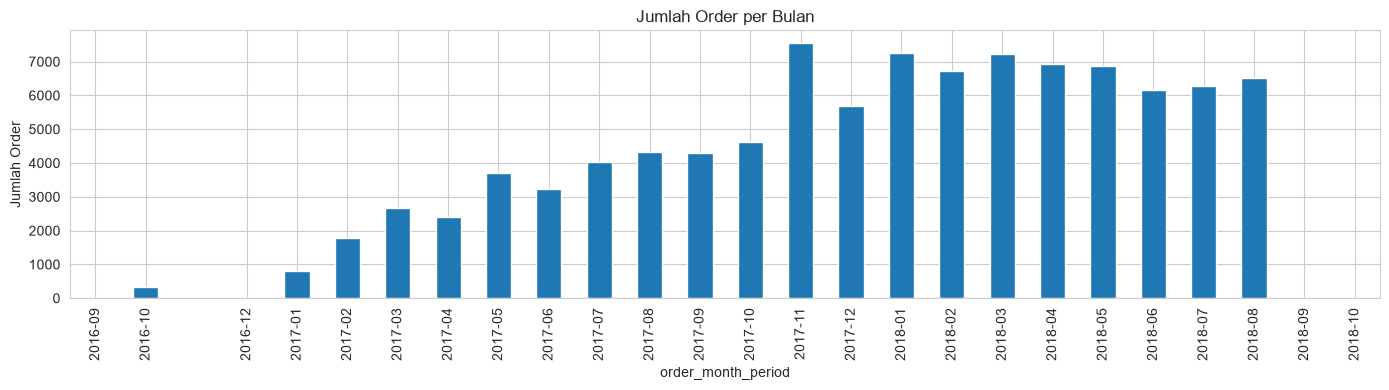

Rentang bulan yang dianggap lengkap: 2017-03 s.d. 2018-08
(Bulan di luar rentang ini di-exclude karena volume order terlalu kecil - ramp-up awal atau data collection berhenti)


In [2]:
orders["order_month_period"] = orders["order_purchase_timestamp"].dt.to_period("M")
monthly_counts = orders.groupby("order_month_period")["order_id"].nunique()

fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(kind="bar", ax=ax)
ax.set_title("Jumlah Order per Bulan")
ax.set_ylabel("Jumlah Order")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

median_monthly = monthly_counts.median()
threshold = median_monthly * 0.5
complete_months = monthly_counts[monthly_counts >= threshold]

print(f"Rentang bulan yang dianggap lengkap: {complete_months.index.min()} s.d. {complete_months.index.max()}")
print(f"(Bulan di luar rentang ini di-exclude karena volume order terlalu kecil - ramp-up awal atau data collection berhenti)")


---
## 2. Sensitivity Analysis — Bandingkan Beberapa Panjang Prediction Window

**Jangan pilih window cuma karena imbalance-nya paling enak.** Di sini kita hitung positive cases & rate untuk 3, 4, dan 6 bulan — perbandingan ini yang jadi dasar diskusi business horizon di langkah berikutnya, bukan keputusan otomatis.


In [3]:
def build_window(prediction_months, complete_months, orders):
    """Hitung observation/prediction window + eligible population + positive cases untuk N bulan prediction window."""
    complete_period_start = complete_months.index.min()
    complete_period_end = complete_months.index.max()

    prediction_start_period = complete_period_end - (prediction_months - 1)
    prediction_start = prediction_start_period.to_timestamp()
    prediction_end = complete_period_end.to_timestamp(how="end")

    observation_start = complete_period_start.to_timestamp()
    observation_end = prediction_start

    obs_orders = orders[
        (orders["order_purchase_timestamp"] >= observation_start) &
        (orders["order_purchase_timestamp"] < observation_end)
    ]
    pred_orders = orders[
        (orders["order_purchase_timestamp"] >= prediction_start) &
        (orders["order_purchase_timestamp"] <= prediction_end)
    ]

    eligible_customers = set(obs_orders["customer_unique_id"].dropna().unique())
    customers_repeat_in_pred = set(
        pred_orders[pred_orders["customer_unique_id"].isin(eligible_customers)]["customer_unique_id"].unique()
    )

    total_cases = len(eligible_customers)
    positive_cases = len(customers_repeat_in_pred)
    positive_rate = positive_cases / total_cases * 100 if total_cases else 0
    imbalance = (total_cases - positive_cases) / positive_cases if positive_cases else np.nan

    return {
        "prediction_window_months": prediction_months,
        "observation_start": observation_start,
        "observation_end": observation_end,
        "prediction_start": prediction_start,
        "prediction_end": prediction_end,
        "observation_days": (observation_end - observation_start).days,
        "eligible_customers": total_cases,
        "positive_cases": positive_cases,
        "positive_rate_pct": round(positive_rate, 2),
        "imbalance_ratio": round(imbalance, 1),
    }

sensitivity_results = [
    build_window(m, complete_months, orders) for m in [3, 4, 6]
]
sensitivity_df = pd.DataFrame(sensitivity_results)
print("Sensitivity Analysis — Prediction Window 3 vs 4 vs 6 bulan:")
sensitivity_df[["prediction_window_months", "observation_days", "eligible_customers",
                 "positive_cases", "positive_rate_pct", "imbalance_ratio"]]


Sensitivity Analysis — Prediction Window 3 vs 4 vs 6 bulan:


,prediction_window_months,observation_days,eligible_customers,positive_cases,positive_rate_pct,imbalance_ratio
0,3,457,75047,431,0.57,173.1
1,4,426,68420,547,0.80,124.1
2,6,365,54738,664,1.21,81.4


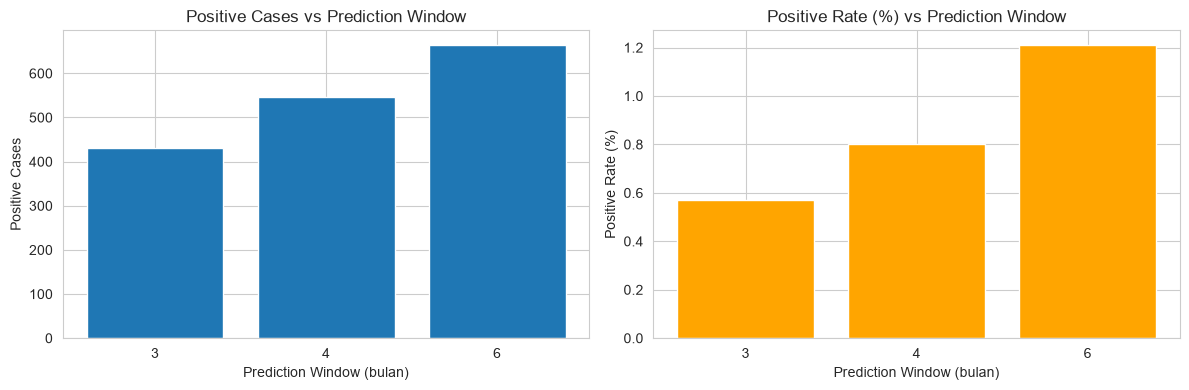

Interpretasi kasar (isi manual setelah lihat angka & chart di atas):
- Kalau rate naik signifikan dari 3->6 bulan: horizon pendek memang 'sparse', bukan berarti data salah.
- Kalau rate relatif stagnan: menambah window tidak banyak membantu, imbalance memang karakteristik problem ini.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(sensitivity_df["prediction_window_months"].astype(str), sensitivity_df["positive_cases"])
axes[0].set_title("Positive Cases vs Prediction Window")
axes[0].set_xlabel("Prediction Window (bulan)")
axes[0].set_ylabel("Positive Cases")

axes[1].bar(sensitivity_df["prediction_window_months"].astype(str), sensitivity_df["positive_rate_pct"], color="orange")
axes[1].set_title("Positive Rate (%) vs Prediction Window")
axes[1].set_xlabel("Prediction Window (bulan)")
axes[1].set_ylabel("Positive Rate (%)")

plt.tight_layout()
plt.show()

print("Interpretasi kasar (isi manual setelah lihat angka & chart di atas):")
print("- Kalau rate naik signifikan dari 3->6 bulan: horizon pendek memang 'sparse', bukan berarti data salah.")
print("- Kalau rate relatif stagnan: menambah window tidak banyak membantu, imbalance memang karakteristik problem ini.")


---
## 3. Pilih Window Final — Berdasarkan Business Horizon

**Business horizon yang menentukan prediction window, bukan sebaliknya.** Isi pertanyaan ini secara eksplisit sebelum memilih:

> *"Customer mana yang kemungkinan melakukan repeat purchase dalam [N] bulan ke depan?"* — N ini yang harus dijawab dari sudut pandang business action (kapan tim marketing/CRM realistis bisa follow-up), bukan dari sudut pandang "N mana yang bikin model paling gampang".

Ganti `FINAL_PREDICTION_WINDOW_MONTHS` di bawah setelah melihat hasil sensitivity analysis & mempertimbangkan business horizon yang masuk akal.


In [5]:
FINAL_PREDICTION_WINDOW_MONTHS = 6  # dipilih setelah sensitivity analysis: 3/4/6 bulan dibandingkan

BUSINESS_JUSTIFICATION = (
    "6 bulan dipilih sebagai prediction window final berdasarkan sensitivity analysis: positive rate naik "
    "signifikan dari 0.57% (3 bulan) menjadi 1.21% (6 bulan), dan imbalance ratio membaik dari 173:1 menjadi "
    "81:1 — kenaikan lebih dari 2x lipat ini menunjukkan bahwa horizon pendek (3 bulan) memang terlalu sempit "
    "untuk menangkap pola repeat purchase yang valid, bukan sekadar noise. Dari sisi business horizon, 6 bulan "
    "juga tetap masuk akal sebagai jendela untuk program retensi/loyalty jangka menengah (bukan follow-up "
    "instan, tapi masih dalam rentang yang actionable untuk tim CRM). Trade-off yang disadari: observation "
    "window jadi lebih pendek (365 hari vs 457 hari) dan eligible population berkurang ~27% (75,047 -> 54,738), "
    "tapi ini dianggap sepadan dengan kualitas sinyal target yang lebih baik. Imbalance 81:1 tetap ekstrem dan "
    "akan ditangani lewat PR-AUC sebagai metrik utama, class_weight='balanced'/scale_pos_weight, dan threshold "
    "tuning — bukan dengan mengubah window lebih jauh lagi hanya demi imbalance yang lebih 'enak'."
)

final_window = build_window(FINAL_PREDICTION_WINDOW_MONTHS, complete_months, orders)

observation_start = final_window["observation_start"]
observation_end = final_window["observation_end"]
prediction_start = final_window["prediction_start"]
prediction_end = final_window["prediction_end"]

print(f"WINDOW FINAL DIPILIH: {FINAL_PREDICTION_WINDOW_MONTHS} bulan")
print(f"OBSERVATION WINDOW : {observation_start.date()} s.d. {observation_end.date()}")
print(f"PREDICTION WINDOW  : {prediction_start.date()} s.d. {prediction_end.date()}")
print(f"\nEligible customer : {final_window['eligible_customers']:,}")
print(f"Positive cases     : {final_window['positive_cases']:,}")
print(f"Positive rate      : {final_window['positive_rate_pct']:.2f}%")
print(f"Imbalance ratio    : {final_window['imbalance_ratio']:.1f} : 1")
print(f"\nJustifikasi bisnis: {BUSINESS_JUSTIFICATION}")


WINDOW FINAL DIPILIH: 6 bulan
OBSERVATION WINDOW : 2017-03-01 s.d. 2018-03-01
PREDICTION WINDOW  : 2018-03-01 s.d. 2018-08-31

Eligible customer : 54,738
Positive cases     : 664
Positive rate      : 1.21%
Imbalance ratio    : 81.4 : 1

Justifikasi bisnis: 6 bulan dipilih sebagai prediction window final berdasarkan sensitivity analysis: positive rate naik signifikan dari 0.57% (3 bulan) menjadi 1.21% (6 bulan), dan imbalance ratio membaik dari 173:1 menjadi 81:1 — kenaikan lebih dari 2x lipat ini menunjukkan bahwa horizon pendek (3 bulan) memang terlalu sempit untuk menangkap pola repeat purchase yang valid, bukan sekadar noise. Dari sisi business horizon, 6 bulan juga tetap masuk akal sebagai jendela untuk program retensi/loyalty jangka menengah (bukan follow-up instan, tapi masih dalam rentang yang actionable untuk tim CRM). Trade-off yang disadari: observation window jadi lebih pendek (365 hari vs 457 hari) dan eligible population berkurang ~27% (75,047 -> 54,738), tapi ini dianggap

---
## 4. ⛔ DECISION GATE (final, dari window yang sudah dipilih)

```
Positive cases cukup?
       │
   ┌───┴───┐
  YES      NO
   │        │
   ↓        ↓
Classification   Reframe target
```

> Catatan: "cukup" di sini bukan cuma soal jumlah absolut (>= 200), tapi juga soal apakah imbalance-nya masih bisa ditangani lewat teknik standar (class weighting, PR-AUC, threshold tuning). Imbalance ekstrem BUKAN otomatis alasan reframe — itu ditangani di level modeling, bukan di level keputusan target.


In [6]:
MIN_POSITIVE_CASES = 200

positive_cases = final_window["positive_cases"]
total_cases = final_window["eligible_customers"]

if positive_cases >= MIN_POSITIVE_CASES:
    decision = "CLASSIFICATION"
    print(f"✅ DECISION: Positive cases ({positive_cases:,}) >= threshold ({MIN_POSITIVE_CASES}).")
    print("   -> Lanjut sebagai REPEAT PURCHASE CLASSIFICATION (Logistic / RF / XGBoost).")
    print(f"   -> WAJIB pakai PR-AUC sebagai metrik utama, class_weight='balanced' / scale_pos_weight, threshold tuning")
    print(f"      (imbalance ratio {final_window['imbalance_ratio']:.1f}:1 — ekstrem, tapi ditangani lewat teknik ini, bukan reframe otomatis).")
    print("   -> SMOTE BUKAN wajib — evaluasi dulu apakah class weighting + threshold tuning sudah cukup.")
else:
    decision = "REFRAME"
    print(f"⚠️  DECISION: Positive cases ({positive_cases:,}) < threshold ({MIN_POSITIVE_CASES}).")
    print("   -> Reframe target jadi propensity score / target alternatif, atau evaluasi ulang window di bagian 3.")


✅ DECISION: Positive cases (664) >= threshold (200).
   -> Lanjut sebagai REPEAT PURCHASE CLASSIFICATION (Logistic / RF / XGBoost).
   -> WAJIB pakai PR-AUC sebagai metrik utama, class_weight='balanced' / scale_pos_weight, threshold tuning
      (imbalance ratio 81.4:1 — ekstrem, tapi ditangani lewat teknik ini, bukan reframe otomatis).
   -> SMOTE BUKAN wajib — evaluasi dulu apakah class weighting + threshold tuning sudah cukup.


---
## 5. Eligible Population & Target (Fase 7.0 & Fase 7) — dari window final


In [7]:
obs_orders = orders[
    (orders["order_purchase_timestamp"] >= observation_start) &
    (orders["order_purchase_timestamp"] < observation_end)
].copy()

pred_orders = orders[
    (orders["order_purchase_timestamp"] >= prediction_start) &
    (orders["order_purchase_timestamp"] <= prediction_end)
].copy()

eligible_customers = set(obs_orders["customer_unique_id"].dropna().unique())
customers_repeat_in_pred = set(
    pred_orders[pred_orders["customer_unique_id"].isin(eligible_customers)]["customer_unique_id"].unique()
)

target_df = pd.DataFrame({"customer_unique_id": list(eligible_customers)})
target_df["target"] = target_df["customer_unique_id"].isin(customers_repeat_in_pred).astype(int)

print(f"Populasi target (eligible customer): {len(target_df):,}")
print(f"Target=1 (repeat di prediction window): {target_df['target'].sum():,}")


Populasi target (eligible customer): 54,738
Target=1 (repeat di prediction window): 664


---
## 6. Data Leakage Audit (Fase 7.2)


In [8]:
assert obs_orders["order_purchase_timestamp"].max() < observation_end, \
    "LEAKAGE DETECTED: ada order di obs_orders yang melewati observation_end!"
assert obs_orders["order_purchase_timestamp"].min() >= observation_start, \
    "Ada order di obs_orders yang sebelum observation_start (di luar window yang diinginkan)."

print("✅ Leakage audit lolos: semua feature akan dihitung HANYA dari rentang "
      f"{observation_start.date()} s.d. {observation_end.date()}.")


✅ Leakage audit lolos: semua feature akan dihitung HANYA dari rentang 2017-03-01 s.d. 2018-03-01.


---
## 7. Feature Engineering — `customer_features_observation` (Fase 7.3)


In [9]:
features = obs_orders.groupby("customer_unique_id").agg(
    order_count=("order_id", "nunique"),
    total_spending=("transaction_value", "sum"),
    avg_order_value=("transaction_value", "mean"),
    last_order_date_observation=("order_purchase_timestamp", "max"),
    avg_review_score=("review_score", "mean"),
    avg_delivery_days=("order_delivered_customer_date", lambda x: (
        (x - obs_orders.loc[x.index, "order_purchase_timestamp"]).dt.days.mean()
    )),
    unique_categories=("n_categories", "sum"),
).reset_index()

features["days_since_last_order"] = (observation_end - features["last_order_date_observation"]).dt.days

ml_dataset = features.merge(target_df, on="customer_unique_id", how="inner")

print(f"customer_features_observation shape: {ml_dataset.shape}")
print(f"Positive rate di ml_dataset: {ml_dataset['target'].mean()*100:.2f}%")
ml_dataset.head()


customer_features_observation shape: (54738, 10)
Positive rate di ml_dataset: 1.21%


,customer_unique_id,order_count,total_spending,avg_order_value,last_order_date_observation,avg_review_score,avg_delivery_days,unique_categories,days_since_last_order,target
0,0000f46a3911fa3c0805444483337064,1,86.22,86.22,2017-03-10 21:05:03,3.0,25.0,1.0,355,0
1,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,2017-10-12 20:29:41,4.0,20.0,1.0,139,0
2,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,2017-11-14 19:45:42,5.0,13.0,1.0,106,0
3,00053a61a98854899e70ed204dd4bafe,1,419.18,419.18,2018-02-28 11:15:41,1.0,16.0,1.0,0,0
4,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,2017-03-04 23:32:12,4.0,4.0,1.0,361,0


---
## 8. Time-Based Validation Setup (Fase 7.4)

Untuk Olist, **time-based validation lebih penting daripada random split** (mensimulasikan prediksi masa depan). Split random-stratified di bawah ini untuk MVP awal — pertimbangkan rolling/expanding time split di notebook 08 kalau data historis mendukung.


In [10]:
from sklearn.model_selection import train_test_split

X = ml_dataset.drop(columns=["customer_unique_id", "target", "last_order_date_observation"])
y = ml_dataset["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} ({y_train.mean()*100:.2f}% positive)")
print(f"Test : {X_test.shape[0]:,} ({y_test.mean()*100:.2f}% positive)")


Train: 43,790 (1.21% positive)
Test : 10,948 (1.21% positive)


---
## 9. Simpan Dataset & Dokumentasi Window Final


In [11]:
ml_dataset.to_csv(DATA_DIR / "ml_dataset_observation.csv", index=False)

window_summary = pd.DataFrame([{
    **final_window,
    "decision": decision,
    "business_justification": BUSINESS_JUSTIFICATION,
}])
window_summary.to_csv(DATA_DIR / "window_decision_summary.csv", index=False)

sensitivity_df.to_csv(DATA_DIR / "window_sensitivity_analysis.csv", index=False)

print(f"Tersimpan: {DATA_DIR / 'ml_dataset_observation.csv'} (shape: {ml_dataset.shape})")
print(f"Tersimpan: {DATA_DIR / 'window_decision_summary.csv'}")
print(f"Tersimpan: {DATA_DIR / 'window_sensitivity_analysis.csv'} (untuk dokumentasi sensitivity analysis)")


Tersimpan: ..\data_processed\ml_dataset_observation.csv (shape: (54738, 10))
Tersimpan: ..\data_processed\window_decision_summary.csv
Tersimpan: ..\data_processed\window_sensitivity_analysis.csv (untuk dokumentasi sensitivity analysis)


---
## Definition of Done (Fase 7 — Decision Gate)

- [ ] Distribusi tanggal aktual sudah diplot dan dipahami
- [ ] **Sensitivity analysis** dijalankan untuk 3/4/6 bulan, dibandingkan positive cases & rate
- [ ] Window final dipilih berdasarkan **business horizon** (justifikasi ditulis eksplisit), bukan cuma cari imbalance paling enak
- [ ] Eligible population & target didefinisikan presisi dari window final
- [ ] Decision Gate dijalankan: imbalance ekstrem TIDAK otomatis berarti reframe, ditangani lewat teknik modeling
- [ ] Leakage audit lolos, feature dibangun dari `customer_features_observation` (bukan `customer_analytics_full`)
- [ ] Dataset final + sensitivity analysis tersimpan untuk dokumentasi

**Lanjut ke:** `08_modeling.ipynb`
